# Confusion Matrices
Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import plotting
# standardize colors
from cycler import cycler 

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [ ]:
prediction_dir = 'predictions/'

y_true = np.argmax(np.load("y_test.npy"), axis=1)
y_baseline = np.argmax(np.load("y_baseline.npy"), axis=1) # generated from baseline keras model
#classes = ['0', '1','2','3','4','5','6','7','8','9']
classes = [i for i in range(0,10)]
#np.load("classes.npy", allow_pickle=True)
classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [29]:
print(y_true)
# Select how many of the predictions to inclue. The prediction.npy includes 300 inferences, but a lot of them errored to zero-vector
selection = 100

y_true = y_true[:selection]

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3 7 4 6 4 3 0 7 0 2 9
 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9 6 0 5 4 9 9 2 1 9 4 8
 7 3 9 7 4 4 4 9 2 5 4 7 6 7 9 0 5 8 5 6 6 5 7 8 1 0 1 6 4 6 7 3 1 7 1 8 2
 0 2 9 9 5 5 1 5 6 0 3 4 4 6 5 4 6 5 4 5 1 4 4 7 2 3 2 7 1 8 1 8 1 8 5 0 8
 9 2 5 0 1 1 1 0 9 0 3 1 6 4 2 3 6 1 1 1 3 9 5 2 9 4 5 9 3 9 0 3 6 5 5 7 2
 2 7 1 2 8 4 1 7 3 3 8 8 7 9 2 2 4 1 5 9 8 7 2 3 0 4 4 2 4 1 9 5 7 7 2 8 2
 6 8 5 7 7 9 1 8 1 8 0 3 0 1 9 9 4 1 8 2 1 2 9 7 5 9 2 6 4 1 5 8 2 9 2 0 4
 0 0 2 8]


In [30]:
def dut_cm(prediction_path, plotname):
    y_dut = np.argmax(np.load(prediction_path)[:selection], axis=1)
    cm = confusion_matrix(y_true, y_dut)

    fig, ax = plt.subplots(figsize=(10, 6))
    plotting.plot_confusion_matrix(cm, classes, normalize=True, title=plotname)

    #plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/CM_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

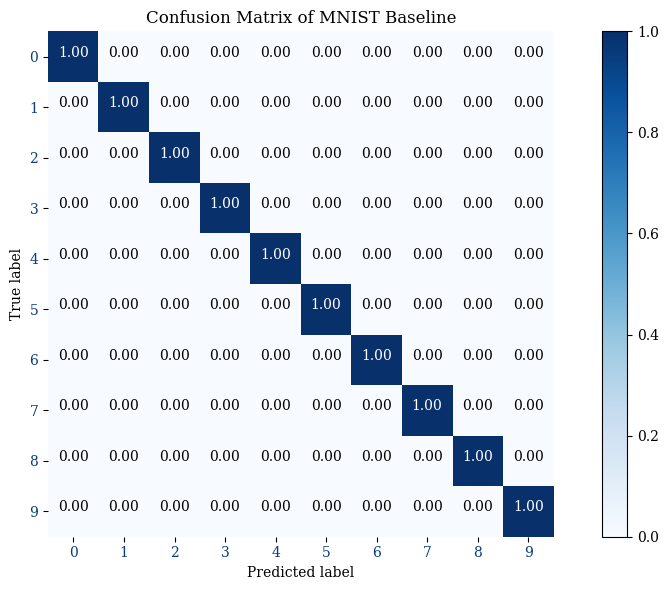

Searching for predictions in predictions/
predictions/y_dut_HGQ-AdaptiveHP.npy


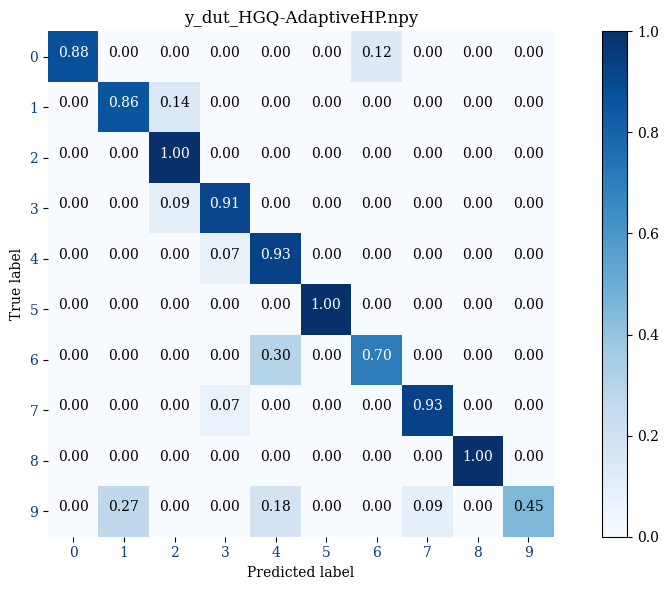

In [32]:
from pathlib import Path

dut_cm('y_baseline.npy','Confusion Matrix of MNIST Baseline')

paths = []
y_true = y_true[:selection]

print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    print(prediction_path)
    dut_cm(prediction_path, str(prediction_path.name))
    paths.append(prediction_path)

Choose the plots you want to finalize for report

In [17]:
for p in paths:
    print(p)

predictions/y_dut_HGQ-AdaptiveHP.npy


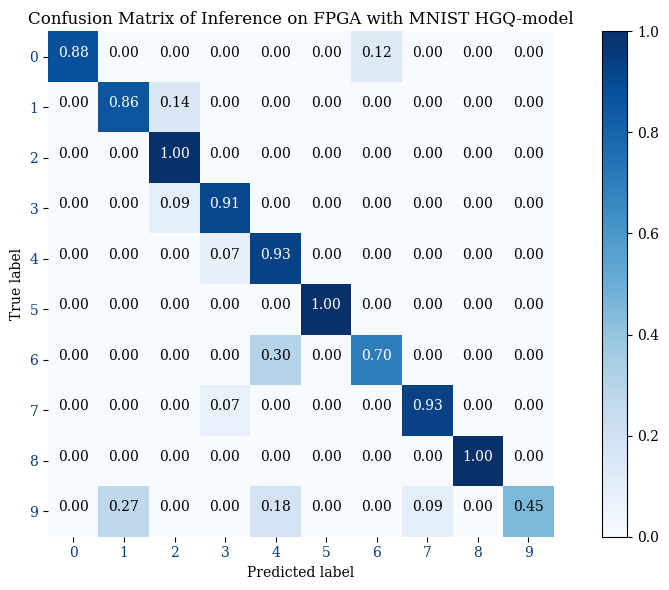

In [18]:
prediction_path = 'predictions/y_dut_HGQ-AdaptiveHP.npy'
plotname = 'Confusion Matrix of Inference on FPGA with MNIST HGQ-model'

dut_cm(prediction_path, plotname)